# Análisis de ventas de videojuegos 

# Introducción

En este proyecto se analiza el comportamiento del mercado de videojuegos a partir de datos históricos de ventas, plataformas, géneros y clasificaciones por edad, con el objetivo de identificar patrones relevantes entre distintas regiones. A través de visualizaciones exploratorias y pruebas estadísticas, se evalúa cómo factores como la región, el tipo de plataforma, el género y la clasificación ESRB influyen en el desempeño comercial y en la percepción de los usuarios, con el fin de extraer conclusiones útiles para la toma de decisiones estratégicas para futuras campañas publicitarías de la tienda online Ice.

# Preparación de los datos

Comenzaremos importando nuestras librerias

In [2]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
from matplotlib import pyplot as plt
from scipy import stats as st

A continuacion cargamos el DataFrame "games.csv"

In [3]:
# Se le asigna la variable "games"
games = pd.read_csv(r"C:\Users\sebas\Downloads\Datasets\games.csv")

# Exploración de los datos

Utilizamos los metodos .info(), .head() y .tail() para familiarizarnos con nuestros datos

In [4]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
games.tail()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16710,Samurai Warriors: Sanada Maru,PS3,"2,016.00",Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,"2,006.00",Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,"2,016.00",Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,"2,003.00",Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN
16714,Winning Post 8 2016,PSV,"2,016.00",Simulation,0.00,0.00,0.01,0.00,NaN,NaN,NaN



Al ejecutar .info() observamos un DataFrame con 16715 filas y 11 columnas. Existen valores ausentes en varias columnas, destacando critic_score, user_score y rating, lo que requiere un análisis cuidadoso para su tratamiento.

La columna year_of_release se encuentra como float64 debido a la presencia de valores nulos, aunque conceptualmente representa un año y puede convertirse a tipo entero.

La columna user_score está almacenada como object debido a valores no numéricos como "tbd", por lo que será necesario limpiarla antes de convertirla a tipo numérico. Para esto convertiremos todas las celdas con "tbd" a valores nulos.

La columna critic_score se mantiene como float64, lo cual es adecuado dada la existencia de valores ausentes.

# Procesamiento de los datos

## Encabezados

Debido a que los encabezados ya se encuentran en formato snake_case, unicamente los transformaremos a minúsculas

In [7]:
games.columns = games.columns.str.lower()    
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

## Tipo de datos

Cambiamos el tipo de datos de las columnas "year_of_release" y "user_score". Reemplazaremos las filas que contienen "tbd" por valores nulos para una conversión de datos exitosa.

In [8]:
# Convertimos "year_of_release" a int
games["year_of_release"] = games["year_of_release"].astype("Int64")

# Creamos valores nulos en las filas que contienen "tbd" 
games["user_score"] = pd.to_numeric(games["user_score"].replace("tbd", pd.NA))

# Convertimos "user_score" a float
games["user_score"] = games["user_score"].astype("float64")


print(games["year_of_release"].dtype)
print(games["user_score"].dtype)

Int64
float64


## Columna "total_sales"

A continuación creamos la columna "total_sales" 

In [9]:
# Sumamos las ventas registradas en nuestro DataFrame

games["total_sales"] = games["na_sales"] + games["eu_sales"] + games["jp_sales"] + games["other_sales"]

games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


En esta etapa se estandarizaron los nombres de las columnas a minúsculas y se realizó una revisión inicial de la estructura y calidad de los datos.

La columna year_of_release fue convertida a tipo entero, ya que se encontraba en formato numérico con decimales. Aunque esto no afecta los cálculos, la conversión mejora la consistencia y claridad del dataset al tratarse únicamente de años.

Se identificaron valores nulos en cinco columnas del DataFrame. Estos valores se mantuvieron sin modificar, ya que en esta etapa no se cuenta con información suficiente para determinar con certeza su origen. Algunas posibles causas incluyen falta de información en la fuente original, errores durante la recolección o exportación de los datos, así como juegos para los cuales ciertos atributos no aplican o no estaban disponibles.

Los valores "tbd" en la columna user_score fueron reemplazados por valores nulos para permitir la conversión de la columna a tipo float, lo que facilita su análisis numérico en etapas posteriores.

# Análisis de datos

## Juegos lanzados por año


Comenzamos filtrando los juegos lanzados en 2016, ya que los datos de ese año están incompletos y podrían distorsionar la tendencia observada en la gráfica. A continuación, agrupamos los datos por año de lanzamiento y contamos la cantidad de juegos lanzados por año.

In [10]:
# Creamos un DataFrame que no incluya el año 2016
games_filtered = games[games["year_of_release"] < 2016]

# Contamos los juegos lanzados por año
games_per_year = games_filtered.groupby("year_of_release")["name"].count()


print(games_per_year)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
Name: name, dtype: int64


Con la información obtenida crearemos un gráfico de líneas que muestra el número de videojuegos lanzados por año, permitiendo visualizar su comportamiento a lo largo del tiempo.

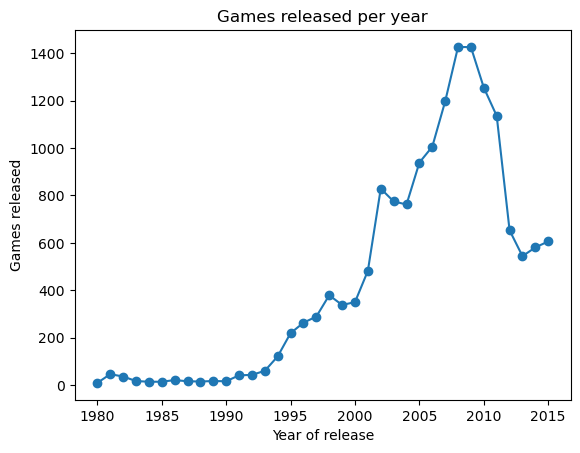

In [11]:
games_per_year.plot(kind="line",
                    marker="o",
                    title="Games released per year",
                    xlabel="Year of release",
                    ylabel="Games released",
                    )

plt.show()

### Conclusión

El gráfico muestra una baja actividad en el periodo de 1980 a 1995. A partir de 1995 se observa el primer incremento considerable, con alrededor de 200 juegos lanzados, seguido de un crecimiento sostenido año con año hasta alcanzar un pico cercano a 1,400 lanzamientos en los años 2008 y 2009.

Posteriormente, se presenta una caída progresiva en el número de lanzamientos, llegando aproximadamente a 500 juegos en el año 2014.

Con base en este comportamiento, la opción más viable para el análisis es considerar los lanzamientos a partir del año 2000, periodo en el que la industria parece estar mejor establecida y la tendencia de lanzamientos aumenta de forma más consistente.

## ¿Qué plataformas generan más dinero y cuáles ya están muriendo?


Ahora que sabemos el periodo que deseamos analizar, crearemos una variable que contenga los juegos que abarcan ese periodo

In [12]:
# Creamos un DataFrame utilizando los datos que habiamos filtrado anteriormente 
games_2000 = games_filtered[games_filtered["year_of_release"] >= 2000]

A continuacion, agrupamos nuestros datos por plataforma y realizamos la suma de las ventas totales para observar el ingreso por plataforma.

In [13]:
platform_sales = games_2000.groupby("platform")["total_sales"].sum()

print(platform_sales)

platform
3DS      242.67
DC         7.41
DS       802.76
GB        29.00
GBA      312.88
GC       196.73
N64       37.30
PC       200.47
PS       140.70
PS2    1,233.56
PS3      927.74
PS4      244.89
PSP      289.53
PSV       49.56
WS         0.96
Wii      891.00
WiiU      77.59
X360     959.72
XB       251.57
XOne     133.17
Name: total_sales, dtype: float64


Ordenamos las ventas de mayor a menor y conservamos las 10 plataformas que mas ingresos generan

In [14]:
platform_sales = platform_sales.sort_values(ascending=False) # Ordenamos

platform_sales = platform_sales.head(10) # Elegimos top 10

Creamos un grafico de barras

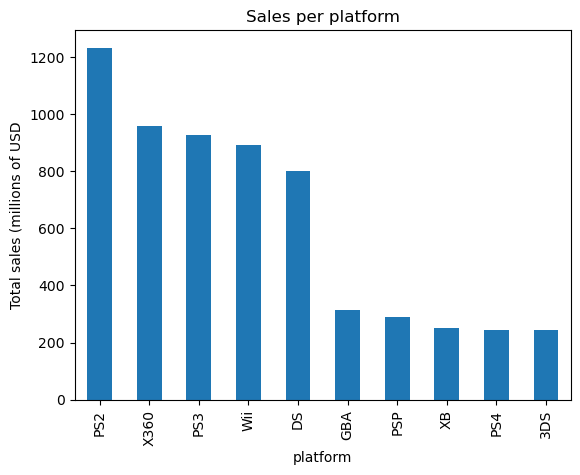

In [15]:
platform_sales.plot(kind="bar",
                   title="Sales per platform",
                   xlabel="platform",
                   ylabel="Total sales (millions of USD")
plt.show()

Al analizar las ventas totales por plataforma a partir del año 2000, se observa que solo un grupo reducido de plataformas concentra la mayor parte de los ingresos, mientras que el resto presenta ventas significativamente menores. Esto indica que el mercado no se distribuye de forma uniforme y que el éxito comercial está fuertemente concentrado en pocas plataformas dominantes.

Por esta razón, resulta más relevante centrar el análisis en las plataformas con mayores ventas acumuladas, ya que son las que tienen mayor impacto en el mercado y ofrecen mejores oportunidades para estrategias comerciales y publicitarias.

Es importante mencionar que existen consolas que fueron lanzadas en años recientes y quedan fuera del top 5 debido a que cuentan con menos ventas a nivel historico

## ¿Cuánto dura una plataforma en el mercado?

Filtramos las 5 consolas mejor vendidas y creamos un DataFrame que incluya unicamente estas 5 consolas

In [16]:

top_platforms = platform_sales.sort_values(ascending=False).head(5).index

top_platform = games_2000[games_2000["platform"].isin(top_platforms)]


Realizamos un grafico de lineas para analizar el ciclo de vida de las plataformas

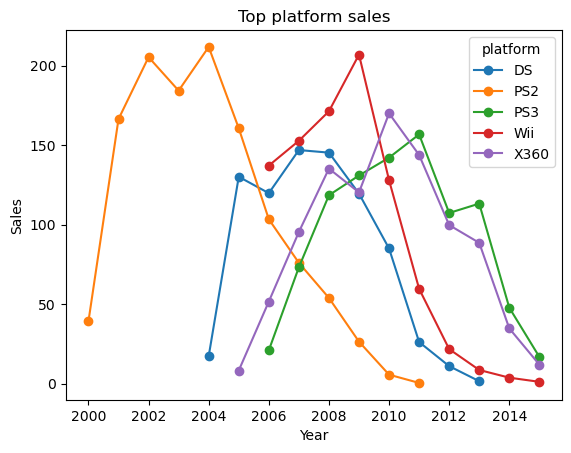

In [17]:
top_pivot = top_platform.pivot_table(index="year_of_release",
                                    columns="platform",
                                    values="total_sales",
                                    aggfunc="sum")

top_pivot.plot(kind="line",
              marker="o",
               title="Top platform sales",
              xlabel="Year",
              ylabel="Sales")

plt.show()

El gráfico nos muestra que las plataformas siguen ciclos de vida similares: un periodo de introducción con ventas bajas, una fase de crecimiento acelerado, un pico de popularidad y finalmente una etapa de declive.

PS2 presenta el ciclo más largo y estable, con varios años consecutivos de ventas altas, lo que indica una adopción sostenida y una base de usuarios amplia. Por otro lado, Wii y DS muestran picos de ventas más pronunciados pero con una caída más rápida, lo que sugiere un éxito explosivo pero menos duradero.

En contraste con el comportamiento típico del mercado, Wii y DS presentan un caso particular. Wii muestra un inicio con ventas elevadas desde sus primeros años, lo que sugiere que su adopción estuvo impulsada por una base de usuarios ya existente y por la presencia simultánea de otras plataformas exitosas de la misma compañía. Por su parte, DS destaca por ser la única plataforma que logró mantener un nivel de ventas cercano a su pico durante más de un año, mostrando una estabilidad poco común frente a la caída pronunciada observada en otras consolas. En conjunto, ambos casos indican que la coexistencia de plataformas exitosas dentro de una misma compañía puede alterar los patrones habituales del ciclo de vida, generando lanzamientos más fuertes o periodos de estabilidad atípicos.

Xbox 360 y PS3 presentan comportamientos similares entre sí, con ciclos más equilibrados y picos de ventas prolongados, lo que refleja una competencia directa entre ambas plataformas durante varios años.

En general, el análisis indica que las plataformas más rentables no son necesariamente las que alcanzan el pico más alto, sino aquellas que logran mantener ventas consistentes durante varios años. Este patrón es clave para identificar plataformas con mayor potencial comercial.

## ¿De que periodo deben tomarse en cuenta los datos?

Seleccionamos el periodo 2007–2015 ya que el grafico nos muestra que estos años representan una etapa en la que las principales plataformas ya se encontraban consolidadas, permitiendo analizar el comportamiento del mercado previo al pico de ventas y su posterior desaceleración.

In [18]:
# Filtramos el DataFrame que contiene nuestras plataformas lideres

top_2007 = top_platform[top_platform["year_of_release"] >= 2007]

## ¿En qué plataformas conviene apostar?

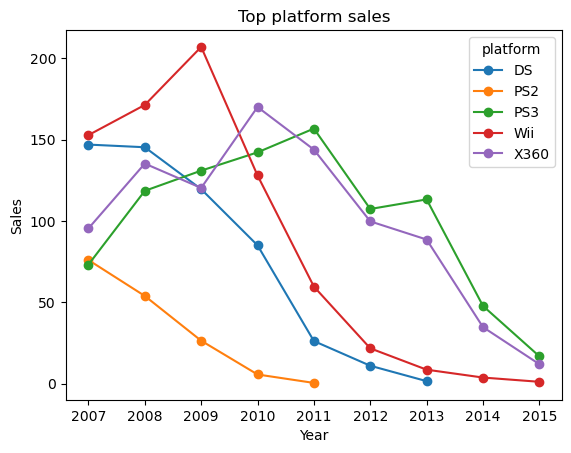

In [19]:
top_2007_piv = top_2007.pivot_table(index="year_of_release",
                                    columns="platform",
                                    values="total_sales",
                                    aggfunc="sum")

top_2007_piv.plot(kind="line",
              marker="o",
               title="Top platform sales",
              xlabel="Year",
              ylabel="Sales")

plt.show()

El análisis del periodo 2007–2015 muestra que las ventas de videojuegos siguen patrones consistentes de crecimiento, pico y declive por plataforma. Sin embargo, al observar el comportamiento agregado del mercado, se identifica que las caídas individuales de plataformas no implican una contracción inmediata del mercado, sino una transición hacia nuevas generaciones de consolas.

Esto indica que el mercado se mantiene activo mientras exista relevo tecnológico, y que la clave no es identificar plataformas específicas, sino reconocer en qué fase del ciclo general se encuentra la industria para tomar decisiones comerciales oportunas.

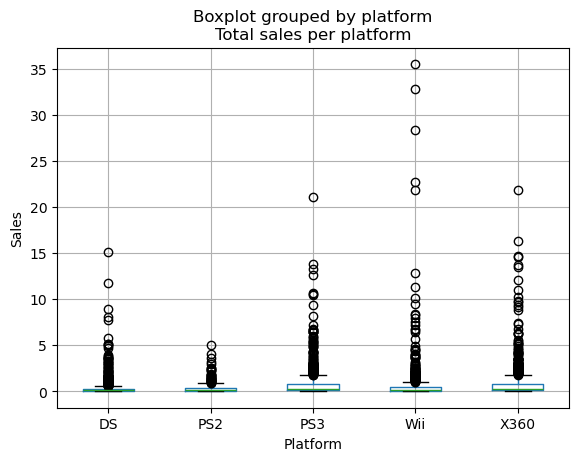

In [20]:
# Creamos un diagrama de caja para comparar la distribución de las ventas de cada plataforma 

top_2007.boxplot(column="total_sales", by="platform")

plt.title("Total sales per platform")
plt.xlabel("Platform")
plt.ylabel("Sales")
plt.show()

El boxplot de ventas globales por plataforma muestra que la mayoría de los juegos presentan ventas bajas en todas las plataformas, con distribuciones fuertemente sesgadas hacia valores pequeños. Las diferencias entre plataformas se manifiestan principalmente en la dispersión y en la presencia de valores atípicos, lo que indica que el desempeño comercial depende de pocos títulos extremadamente exitosos. Las ventas promedio se mantienen bajas y similares entre plataformas, por lo que el mercado presenta un alto nivel de riesgo y dependencia de éxitos puntuales.

## ¿Las reseñas influyen en las ventas?

Seleccionaremos una de nuestras 5 consolas mas vendidas para realizar este análisis, en este caso, analizaremos el impacto de las reseñas en las ventas de XBOX 360

In [21]:
# Filtramos nuestro DataFrame 
xb360 = top_2007[top_2007["platform"] == "X360"]

Creamos un grafico de dispersion para observar el comportamiento de las ventas segun las criticas de la prensa.

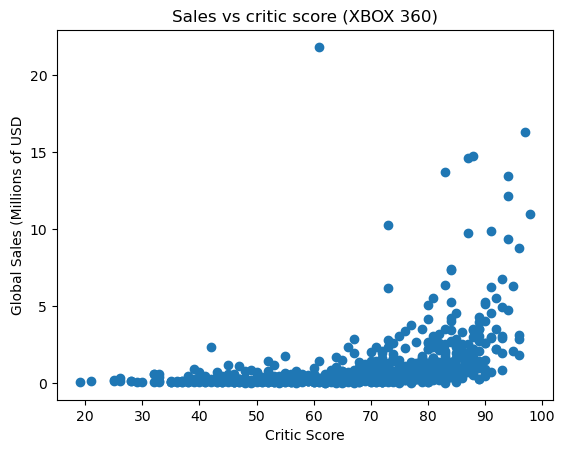

In [22]:
plt.scatter(xb360["critic_score"], xb360["total_sales"])
plt.xlabel("Critic Score")
plt.ylabel("Global Sales (Millions of USD")
plt.title("Sales vs critic score (XBOX 360)")
plt.show()

Crearemos otro grafico de dispersion, esta vez comparando las ventas con las criticas de los usuarios

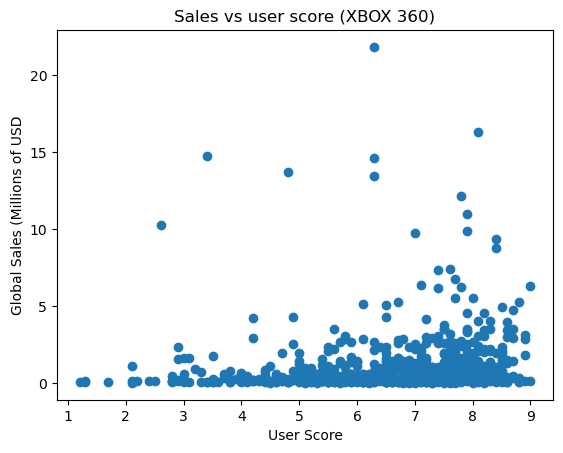

In [23]:
plt.scatter(xb360["user_score"], xb360["total_sales"])
plt.xlabel("User Score")
plt.ylabel("Global Sales (Millions of USD")
plt.title("Sales vs user score (XBOX 360)")
plt.show()

A continuacion, calculamos la correlacion que existe entre las ventas y las critcas de los usuarios y la prensa

In [25]:
xb360[["total_sales", "critic_score", "user_score"]].corr()

,total_sales,critic_score,user_score
total_sales,1.00,0.40,0.11
critic_score,0.40,1.00,0.62
user_score,0.11,0.62,1.00


Se observa que las reseñas de la prensa presentan una relación mayor con las ventas que las reseñas de los usuarios. Sin embargo, esta relación es mínima-moderada (0.40), lo que indica que las críticas no constituyen un factor determinante del éxito comercial de un juego, sino un elemento complementario. En consecuencia, las ventas parecen estar influenciadas por múltiples factores adicionales, como la popularidad de la franquicia, el marketing o el momento de lanzamiento.

## ¿Un juego vende igual en todas las plataformas?

Filtramos los juegos que aparecen en varias plataformas

In [ ]:
# Contamos en cuantas plataformas distintas aparece un juego
multi_games = top_2007.groupby("name")["platform"].nunique()

#  Filtramos los juegos que aparecen en mas de una plataforma
multi_games = multi_games[multi_games > 1].index

# Creamos un DataFrame que unicamente contenga juegos multiplataforma
multiplatform_games = games[games["name"].isin(multi_games)]

Seleccionamos los 5 juegos multiplataforma mas vendidos

In [ ]:
game_sales = multiplatform_games.groupby("name")["total_sales"].sum().reset_index()

top_games_names = game_sales.sort_values(by="total_sales",ascending=False).head()["name"]

top_games = multiplatform_games[multiplatform_games["name"].isin(top_games_names)]

In [ ]:
top_games_piv = top_games.pivot_table(index="name",
                                     columns="platform",
                                     values="total_sales",
                                     aggfunc="sum")

print(top_games_piv)

platform                         DS   PC   PS3   PS4  Wii  WiiU  X360  XOne
name                                                                       
Call of Duty: Black Ops        0.58 1.62 12.63   NaN 1.37   NaN 14.62   NaN
Call of Duty: Black Ops II      NaN 1.52 13.79   NaN  NaN  0.41 13.68   NaN
Call of Duty: Ghosts            NaN 0.69  9.36  3.83  NaN  0.35 10.24  2.92
Call of Duty: Modern Warfare 3  NaN 1.71 13.33   NaN 0.83   NaN 14.73   NaN
Grand Theft Auto V              NaN 1.17 21.05 12.62  NaN   NaN 16.27  5.47


La tabla muestra el fuerte dominio de la franquicia Call of Duty entre los juegos multiplataforma. Sin embargo, se observa que un mismo título no presenta el mismo nivel de ventas en todas las plataformas, concentrando sus mayores resultados en PS3 y Xbox 360, plataformas que se encontraban consolidadas y con una amplia base de usuarios. Esto indica que el desempeño comercial de un juego depende en gran medida de la plataforma en la que se lanza, y no únicamente del título en sí.

## ¿Que generos son mas rentables?

Agrupamos nuestro DataFrame por generos y sumamos las ventas generadas por cada uno

In [ ]:
games_per_genre = top_2007.groupby("genre")["total_sales"].sum()

Creamos un grafico de barras utilizando nuestra agrupacion

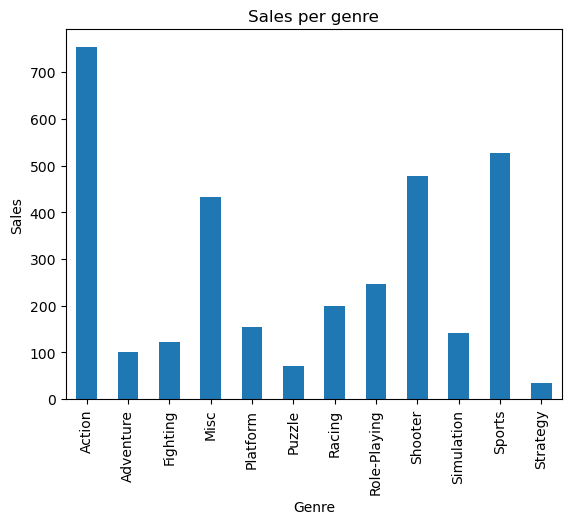

In [ ]:
games_per_genre.plot(kind="bar",
                    title="Sales per genre",
                    xlabel="Genre",
                    ylabel="Sales")

plt.show()

Tambien creamos un diagrama de caja para verificar si las ventas por genero son estables o dependen de grandes exitos para pocisionarse

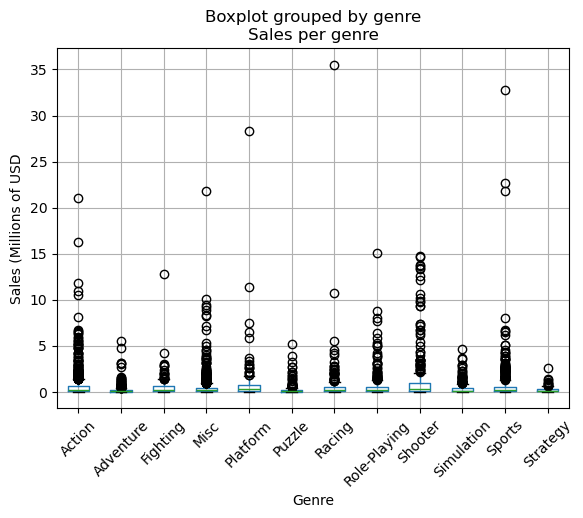

In [ ]:
top_2007.boxplot(column="total_sales", by="genre")

plt.title("Sales per genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()


En conjunto, el análisis muestra que las ventas de videojuegos no dependen de una sola variable, sino de la combinación entre género, plataforma y la presencia de títulos que venden muy por encima del promedio.

La mayoría de los juegos presenta ventas bajas o moderadas, mientras que una parte relevante del mercado se sostiene gracias a títulos que alcanzan entre 2 y 5 millones de dólares en ventas, los cuales representan éxitos comerciales relativamente frecuentes. Los casos que superan ampliamente este rango existen, pero son menos comunes y corresponden a éxitos excepcionales.

Por otro lado, los géneros no garantizan el éxito por sí mismos: algunos muestran ventas más consistentes, mientras que otros dependen en mayor medida de lanzamientos puntuales con ventas extraordinarias. Esto sugiere que el éxito comercial suele concentrarse en pocos títulos dentro de cada género, más que distribuirse de forma uniforme

# Comparacion por regiones

## ¿Cuales son las consolas mas populares en cada región?

### Perfil de usuario por región

Creamos una nueva variable que abarque el periodo que estamos tomando en cuenta para este analisis

In [ ]:
games_2007 = games_filtered[games_filtered["year_of_release"] >= 2007]

Utilizamos .groupby() para crear nuestros perfiles y aplicamos sort_values para seleccionar las 5 consolas mas populares por región

In [ ]:
na_platform_profile = games_2007.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head()

eu_platform_profile = games_2007.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head()

jp_platform_profile = games_2007.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head()

Generamos graficos de barras para comparar la popularidad de las plataformas por región. Tambien utilizaremos boxplots para analizar el comportamiento historico de cada perfil

### NA

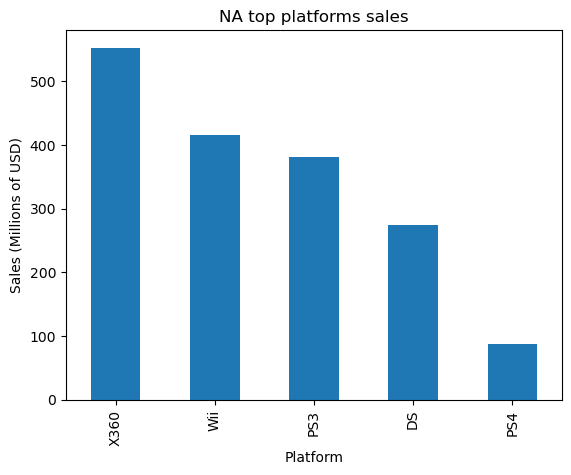

In [ ]:
na_platform_profile.plot(kind="bar",
                        title="NA top platforms sales",
                        xlabel="Platform",
                        ylabel="Sales (Millions of USD)")

plt.show()

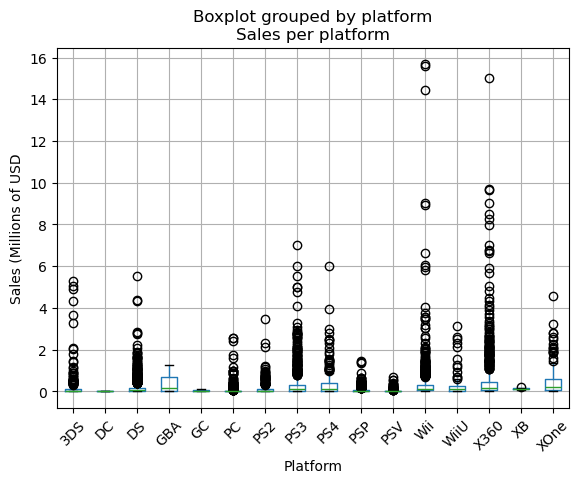

In [ ]:
games_2007.boxplot(column="na_sales", by="platform")

plt.title("Sales per platform")
plt.xlabel("Platform")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

Aunque PS3 y XBOX 360 presentan valores centrales similares, XBOX 360 lidera el mercado debido a que la mayoría de sus títulos se concentran en rangos de ventas más altos y cuenta con más lanzamientos excepcionalmente exitosos, varios de ellos muy por encima del nivel típico de PS3.

Wii supera a PS3 en ventas totales a pesar de tener un nivel típico de ventas más bajo, ya que su desempeño está impulsado por una alta concentración de títulos excepcionalmente exitosos, varios de los cuales superan el mayor éxito observado en PS3.

El posicionamiento de DS se explica principalmente por la presencia de varios lanzamientos excepcionalmente exitosos, ya que sus ventas típicas se concentran en rangos más bajos que las de las otras plataformas líderes.

PS4 presenta un nivel típico de ventas similar al de consolas ya consolidadas como PS3 y XBOX 360, lo que sugiere una buena aceptación del mercado pese a su menor tiempo en circulación. Sin embargo, su menor cantidad de éxitos comerciales se explica por su lanzamiento más reciente, lo que limita la acumulación de títulos de alto impacto. En comparación directa con XBOX One, PS4 muestra un nivel típico de ventas inferior; no obstante, XBOX One no aparece entre las plataformas con mayores ventas totales debido a su menor número de éxitos comerciales. En conjunto, esto apunta a una mayor afinidad del mercado norteamericano por la línea XBOX.

### EU

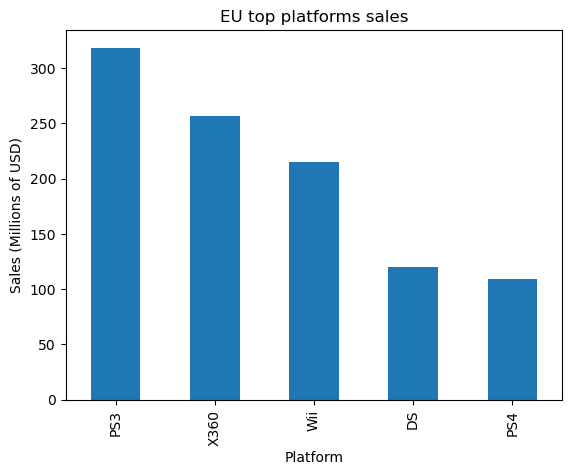

In [ ]:
eu_platform_profile.plot(kind="bar",
                        title="EU top platforms sales",
                        xlabel="Platform",
                        ylabel="Sales (Millions of USD)")

plt.show()

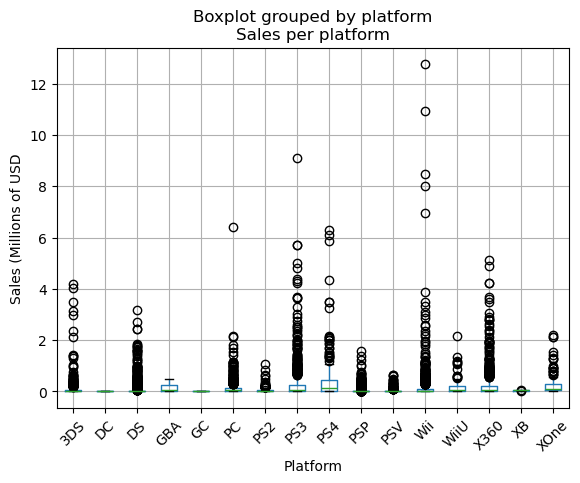

In [ ]:
games_2007.boxplot(column="eu_sales", by="platform")

plt.title("Sales per platform")
plt.xlabel("Platform")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

En la región de EU, PS3 presenta un nivel típico de ventas ligeramente superior al de XBOX 360, así como un mayor número de éxitos comerciales, lo que le permite posicionarse por encima de esta plataforma. Por su parte, Nintendo Wii desciende al tercer lugar pese a mantener un número elevado de grandes éxitos, ya que su nivel de ventas típicas es menor que el observado en NA, lo que indica una mayor dependencia de títulos sobresalientes para sostener su desempeño.

Al comparar las consolas de generación más reciente, se observa una mayor afinidad del mercado europeo por la línea PlayStation: PS4 supera claramente a XBOX One tanto en ventas típicas como en la presencia de títulos con altos niveles de ventas, lo que sugiere una ventaja competitiva más sólida en esta región.




### JP

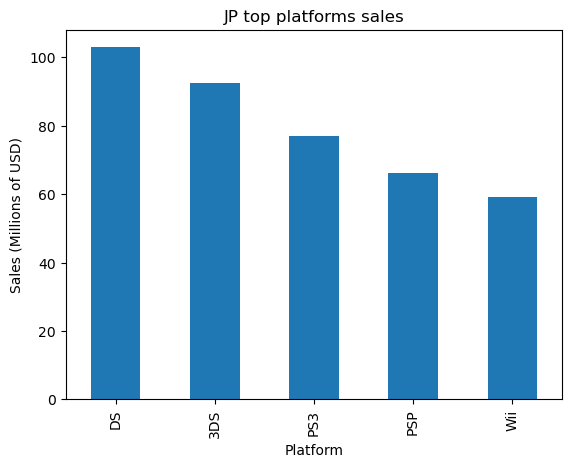

In [ ]:
jp_platform_profile.plot(kind="bar",
                        title="JP top platforms sales",
                        xlabel="Platform",
                        ylabel="Sales (Millions of USD)")

plt.show()

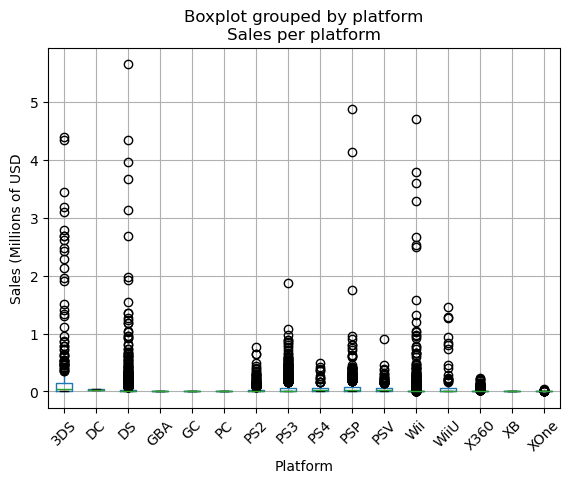

In [ ]:
games_2007.boxplot(column="jp_sales", by="platform")

plt.title("Sales per platform")
plt.xlabel("Platform")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()


Los gráficos nos muestran que la region de Japón tiene el menor consumo de videojuegos de las 3 regiones y una fuerte afinidad por las consolas de su region, apareciendo en el top 5 unicamente consolas de compañías japonesas.

El diagrama de caja nos muestra un numero de ventas típicas bastante bajo en todas las consolas, dependiendo totalmente de éxitos comerciales, a excepción de el Nintendo 3ds la consola con mejores ventas típicas de todas aunque la consola con un mayor numero de éxitos comerciales es el Nintendo DS, ganándole el primer lugar a la Nintendo 3DS. 

Observamos que aunque todas las consolas dependen de éxitos comerciales las únicas consolas que logran acumular un gran numero de ventas sobresalientes son consolas de compañías japonesas, mientras que Xbox 360 y Xbox ONE que son consolas con mayor éxito en las otras dos regiones aquí tienen apenas unas cuantas ventas sobresalientes



### Conclusión

NA presenta el mayor consumo de videojuegos entre las tres regiones, seguido por EU, lo que sugiere que ambas concentran mercados de mayor volumen y mayor potencial para estrategias de inversión amplias. Japón, aunque muestra el menor nivel de consumo y una fuerte dependencia de éxitos comerciales, evidencia una marcada preferencia por consolas de origen local, por lo que representa un mercado distinto que podría abordarse con estrategias más focalizadas y selectivas, en lugar de inversiones masivas.

## ¿Cuales son los generos mas populares en cada región?

### Perfil de usuario por región

Creamos los perfiles de cada región seleccionando los 5 generos mas consumidos en cada una

In [ ]:
na_genre_profile = games_2007.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head()

eu_genre_profile = games_2007.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head()

jp_genre_profile = games_2007.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head()

Generamos graficos de barras para comparar la popularidad de los generos por región. Tambien utilizaremos boxplots para analizar el comportamiento historico de cada perfil.

### NA

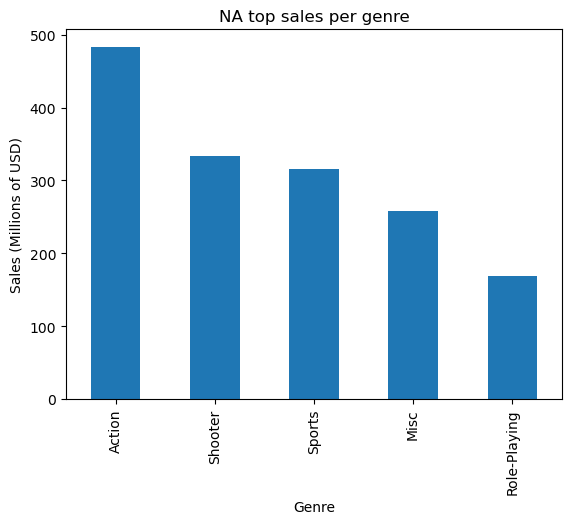

In [ ]:
na_genre_profile.plot(kind="bar",
                        title="NA top sales per genre",
                        xlabel="Genre",
                        ylabel="Sales (Millions of USD)")

plt.show()

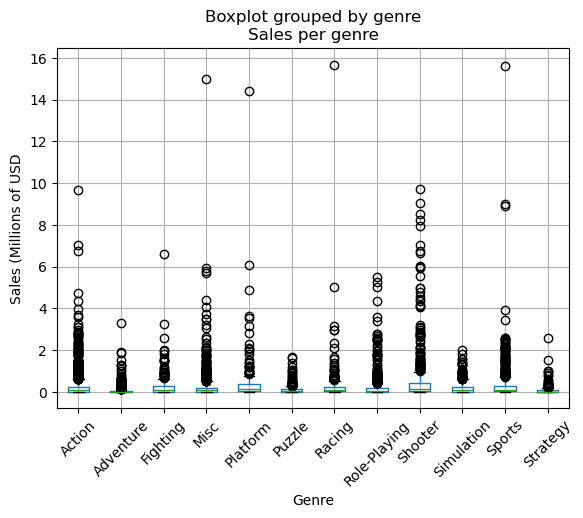

In [ ]:
games_2007.boxplot(column="na_sales", by="genre")

plt.title("Sales per genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

En Norteamérica se observa un nivel bajo de ventas típicas y una fuerte dependencia de ventas sobresalientes. El género Action domina claramente sobre los otros cuatro géneros, los cuales presentan niveles de ventas típicas muy similares entre sí.

Aunque Shooter muestra una mediana ligeramente superior y una mayor cantidad de títulos exitosos, la dominancia de Action se explica por una mayor concentración de ventas sobresalientes, es decir, menos éxitos pero de mayor impacto comercial.

### EU

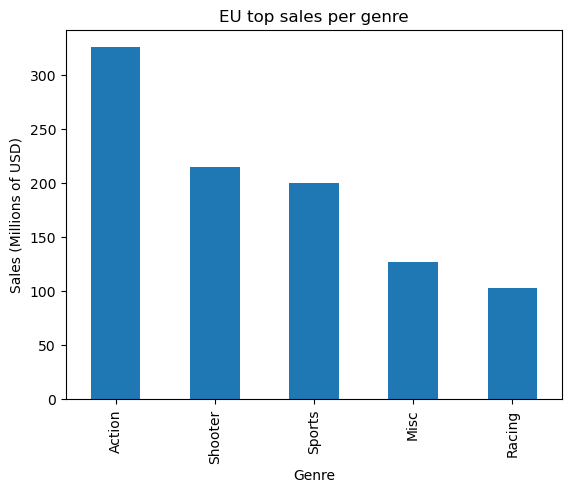

In [ ]:
eu_genre_profile.plot(kind="bar",
                        title="EU top sales per genre",
                        xlabel="Genre",
                        ylabel="Sales (Millions of USD)")

plt.show()

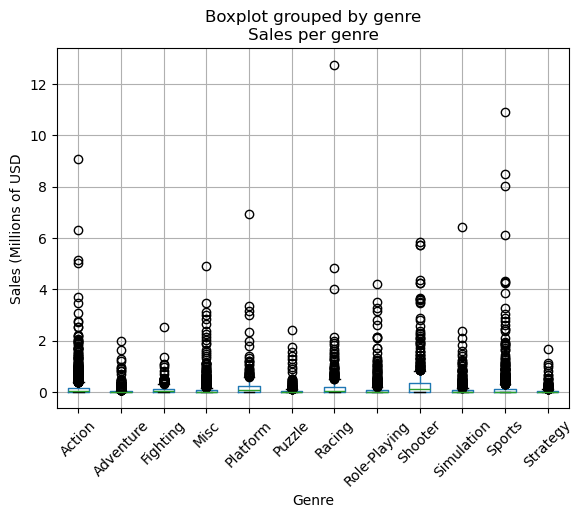

In [ ]:
games_2007.boxplot(column="eu_sales", by="genre")

plt.title("Sales per genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

En Europa también se identifica un género que destaca ampliamente sobre el resto. El comportamiento del mercado es muy similar al de NA, con los mismos cuatro géneros dominantes; la diferencia es que Racing reemplaza a Role-Play en el quinto lugar, impulsado por una mayor cantidad de éxitos comerciales.

A diferencia de NA, aunque Shooter mantiene mejores ventas típicas, no supera a Action en ventas sobresalientes. En esta región, Action domina tanto en concentración como en magnitud de sus éxitos comerciales.

### JP

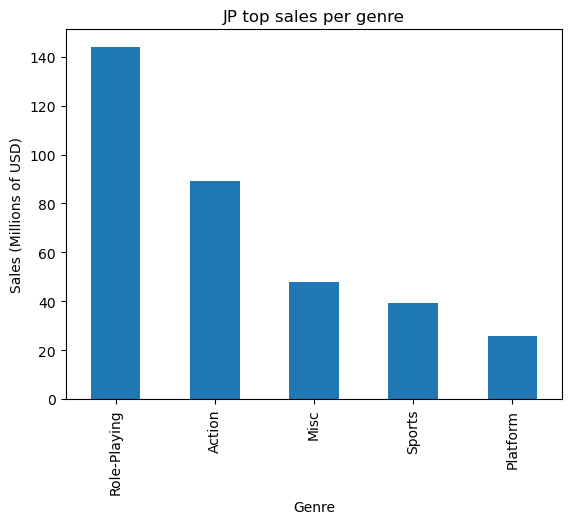

In [ ]:
jp_genre_profile.plot(kind="bar",
                        title="JP top sales per genre",
                        xlabel="Genre",
                        ylabel="Sales (Millions of USD)")

plt.show()

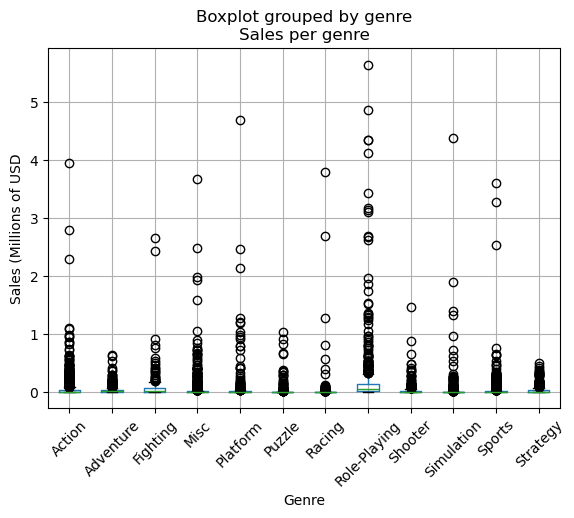

In [ ]:
games_2007.boxplot(column="jp_sales", by="genre")

plt.title("Sales per genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

Japón presenta un patrón distinto, con un dominio claro del género Role-Play. Aunque sus ventas típicas no son altas en términos absolutos, son notoriamente superiores a las del resto de los géneros en la región.

El boxplot muestra una menor dispersión extrema que en NA y EU; sin embargo, Role-Play concentra los éxitos comerciales mejor remunerados, lo que evidencia una preferencia marcada del mercado japonés por este género.

### CONCLUSION 

NA y EU comparten un comportamiento de mercado muy similar, caracterizado por una fuerte dependencia de éxitos comerciales. En ambas regiones, la dominancia de Action se debe principalmente a su concentración de ventas sobresalientes, aun cuando otros géneros pueden presentar ventas típicas comparables o incluso superiores.

En Japón, aunque también existe dependencia de títulos exitosos, el dominio de Role-Play es más estable, apoyado tanto en ventas típicas relativamente más altas como en varios éxitos comerciales de alto rendimiento, lo que sugiere un mercado más focalizado.

Finalmente, Action, Misc y Sports aparecen en el top 5 de las tres regiones, lo que indica una presencia transversal en la industria y un potencial estratégico regionalmente consistente, aun cuando no siempre sean los géneros dominantes.

## ¿Las clasificaciones de ESRB afectan a las ventas en cada región?

Para responder a esta pregunta seguiremos los mismos pasos de las dos preguntas anteriores, crear perfil por region, grafico de barras y boxplot

### Perfil de usuario por región

In [ ]:
na_rating_profile = games_2007.groupby("rating")["na_sales"].sum()

eu_rating_profile = games_2007.groupby("rating")["eu_sales"].sum()

jp_rating_profile = games_2007.groupby("rating")["jp_sales"].sum()

### NA

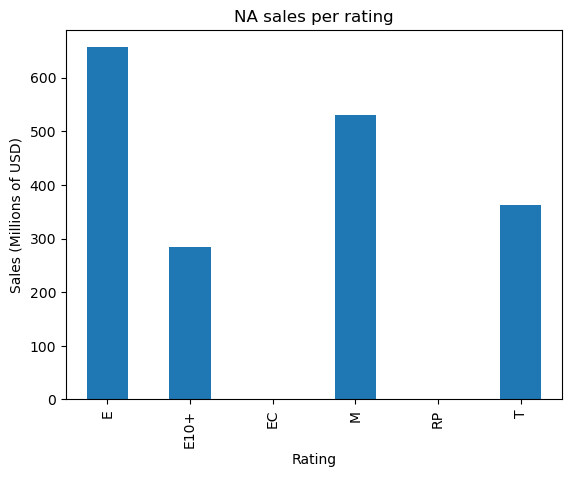

In [ ]:
na_rating_profile.plot(kind="bar",
                        title="NA sales per rating",
                        xlabel="Rating",
                        ylabel="Sales (Millions of USD)")

plt.show()

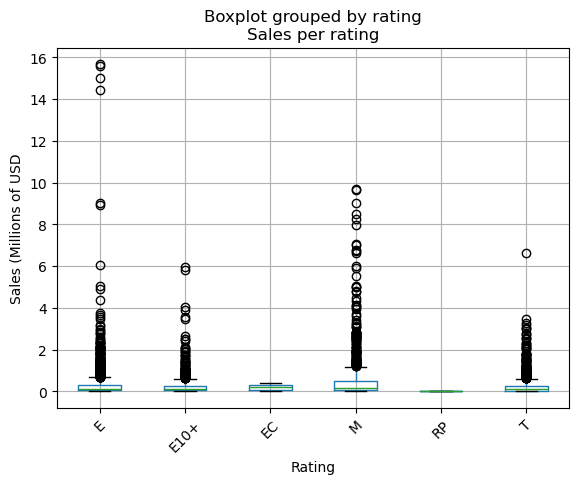

In [ ]:
games_2007.boxplot(column="na_sales", by="rating")

plt.title("Sales per rating")
plt.xlabel("Rating")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

En Norteamérica se observa nuevamente que las ventas están fuertemente influenciadas por éxitos comerciales y ventas sobresalientes, más que por un alto nivel de ventas típicas generalizado. Las clasificaciones E y M dominan claramente el mercado.

Aunque M presenta un nivel de ventas típicas más alto y una mayor concentración de ventas sobresalientes de forma consistente, la clasificación E muestra la presencia de éxitos comerciales significativamente mayores, superando ampliamente a los de M. Esto posiciona a E como la clasificación con mayores ventas totales, a pesar de depender más de casos extremos.

### EU

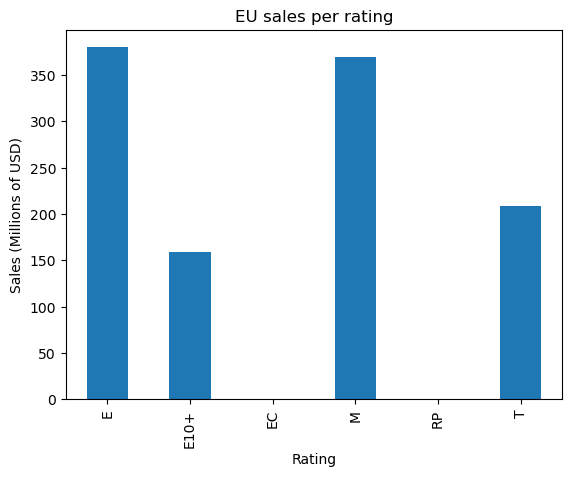

In [ ]:
eu_rating_profile.plot(kind="bar",
                        title="EU sales per rating",
                        xlabel="Rating",
                        ylabel="Sales (Millions of USD)")

plt.show()

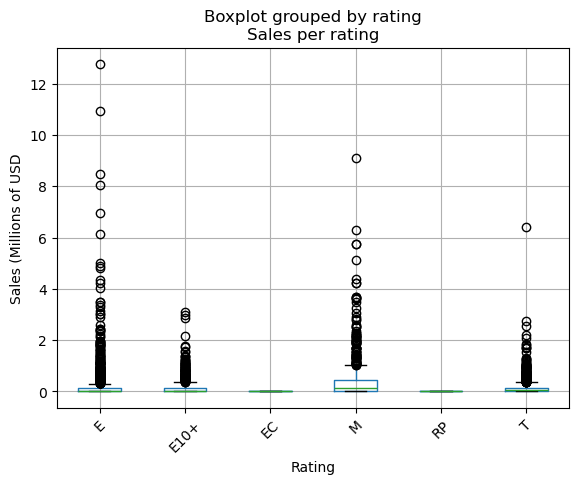

In [ ]:
games_2007.boxplot(column="eu_sales", by="rating")

plt.title("Sales per rating")
plt.xlabel("Rating")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

En Europa se observa un comportamiento de mercado muy similar al de Norteamérica, con una fuerte dominancia de las clasificaciones E y M. Sin embargo, en esta región M logra acercarse más al nivel total de ventas de E, debido a que E presenta un nivel de ventas típicas considerablemente bajo y depende en mayor medida de éxitos sobresalientes.

Por su parte, M mantiene un nivel de ventas típicas visualmente similar al observado en NA. Aunque los valores absolutos varían entre regiones, es válido afirmar que el comportamiento es comparable cuando se analiza en términos relativos y de distribución.

Las clasificaciones E10+ y T conservan un patrón de ventas proporcionalmente similar al de NA, mostrando niveles de ventas típicas y concentraciones de ventas sobresalientes consistentes entre ambas regiones.

### JP

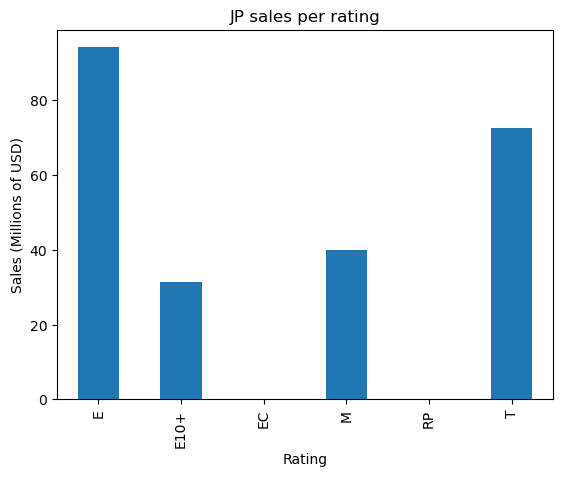

In [ ]:
jp_rating_profile.plot(kind="bar",
                        title="JP sales per rating",
                        xlabel="Rating",
                        ylabel="Sales (Millions of USD)")

plt.show()

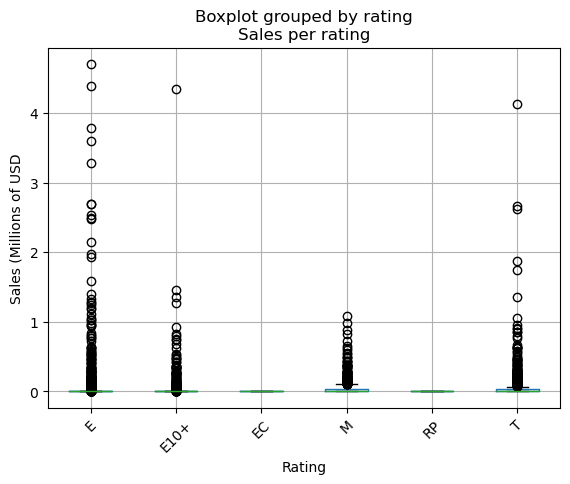

In [ ]:
games_2007.boxplot(column="jp_sales", by="rating")

plt.title("Sales per rating")
plt.xlabel("Rating")
plt.ylabel("Sales (Millions of USD")
plt.xticks(rotation=45)
plt.show()

El mercado japonés presenta un comportamiento claramente distinto al de NA y EU. En esta región, las ventas dependen casi por completo de éxitos comerciales, ya que el nivel de ventas típicas es extremadamente bajo en todas las clasificaciones.

La clasificación E continúa siendo la dominante en ventas totales. Sin embargo, a diferencia de las otras regiones, T ocupa el segundo lugar, impulsada por una mayor concentración de ventas sobresalientes y algunos éxitos comerciales relevantes.

Aunque E10+ muestra ventas sobresalientes más consistentes que M, el nivel de ventas típicas de M es significativamente mayor, lo que posiciona a M ligeramente por encima de E10+ en ventas totales.

El diagrama de caja sugiere una mayor popularidad relativa de los juegos para adolescentes y para todo público, los cuales presentan una mejor concentración de ventas sobresalientes en comparación con E10+ y M.

### CONCLUSION

Los gráficos muestran una presencia dominante de la clasificación E en las tres regiones, ya que, aunque sus ventas típicas suelen ser bajas, presenta una alta concentración de ventas sobresalientes y una mayor cantidad de éxitos comerciales en comparación con el resto de las clasificaciones. Esto puede estar relacionado con su accesibilidad al público general, al no presentar restricciones de edad.

Por otro lado, la clasificación M presenta niveles de ventas típicas consistentemente más altos en las tres regiones, incluso en Japón. Esto podría explicarse por el hecho de que su público objetivo cuenta con mayor autonomía económica. No obstante, su carácter restrictivo podría limitar la magnitud y frecuencia de éxitos comerciales en comparación con la clasificación E.

## CONCLUSION REGIONAL

Al igual que en el mercado global, el éxito de un videojuego en cada región no depende de un solo factor, sino de la interacción entre clasificación, tipo de mercado y comportamiento del consumidor.

Norteamérica y Europa presentan patrones de mercado muy similares, diferenciándose principalmente en la magnitud de las ventas, mientras que Japón muestra un comportamiento claramente distinto, lo que sugiere la necesidad de un análisis más específico y estrategias de lanzamiento diferenciadas para esta región.

# Prueba de hipotesis

## Hipotesis 1
Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


Hipótesis nula (H₀): La calificación promedio de los usuarios en Xbox One es igual a la de PC.

Hipótesis alternativa (H₁): La calificación promedio de los usuarios en Xbox One es diferente a la de PC.

Valor alfa = 0.05

Si el p-value ≤ α, se rechaza la hipótesis nula, de lo contrario, no se rechaza

In [33]:
# Filtramos calificaciones por plataforma:
xbox = games[games["platform"] == "XOne"]["user_score"].dropna()
pc = games[games["platform"] == "PC"]["user_score"].dropna()

# T-test:
results = st.ttest_ind(xbox, pc, equal_var=False)

print("El p-value es:", results.pvalue)

if results.pvalue < alpha_value:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

El p-value es: 4.935072360183574e-06
Se rechaza la hipótesis nula


Se rechaza la hipótesis nula. Las calificaciones promedio de usuarios sí son diferentes entre Xbox One y PC.

## Hipótesis 2
Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.


Hipótesis nula (H₀): La calificación promedio de los usuarios para los géneros Acción y Deportes es la misma.

Hipótesis alternativa (H₁): La calificación promedio de los usuarios para los géneros Acción y Deportes es diferente.

Valor alfa = 0.05

Si el p-value ≤ α, se rechaza la hipótesis nula, de lo contrario, no se rechaza

In [32]:
# Filtramos calificaciones por genero:
action = games[games["genre"] == "Action"]["user_score"].dropna()
sports = games[games["genre"] == "Sports"]["user_score"].dropna()

#T-test:
results = st.ttest_ind(action, sports, equal_var=False)

alpha_value = 0.05

print("El p-value es:", results.pvalue)

if results.pvalue < alpha_value:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

El p-value es: 0.11483818791498288
No se rechaza la hipótesis nula


No se rechaza la hipótesis nula. No hay evidencia estadística suficiente para afirmar que las calificaciones promedio entre Acción y Deportes sean diferentes.

# Conclusion general

El análisis muestra que el desempeño comercial de los videojuegos depende de múltiples factores y no de uno solo.

Norteamérica y Europa presentan mercados similares, con mayor consumo y una fuerte dependencia de éxitos comerciales, lo que las convierte en las regiones con mayor potencial para estrategias de marketing amplias. Japón, en cambio, es un mercado más pequeño y altamente focalizado, con una clara preferencia por consolas y géneros locales, lo que requiere estrategias más específicas.

El éxito por plataforma y género se concentra en pocos casos sobresalientes. Action domina en NA y EU principalmente por la acumulación de ventas sobresalientes, mientras que en Japón el género Role-Playing muestra un dominio más estable. En la clasificación ESRB, E destaca por generar más éxitos comerciales, mientras que M presenta ventas típicas más altas pero con menor alcance.

Las pruebas estadísticas indican que existen diferencias significativas en las calificaciones promedio entre Xbox One y PC, mientras que no se encontraron diferencias significativas entre los géneros de Acción y Deportes.

En conjunto, los resultados sugieren que las decisiones comerciales deben adaptarse al mercado regional y equilibrar el potencial de grandes éxitos con la estabilidad de ventas típicas.